In [ ]:
from PIL import Image
import matplotlib.image as mt
import matplotlib.pyplot as plt
import numpy as np
import io
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torchvision.models import ResNet101_Weights
from collections import defaultdict
import itertools
import seaborn as sns
import cv2

# Libraries for encrypting the data #
!pip install stegano
from stegano import lsb
from stegano.lsb import generators

# To ignore warnings #
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/awsaf49/coco-2017-dataset


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'))

['val2017', 'annotations', 'test2017', 'train2017']


In [ ]:
from PIL import Image

jpg_image = Image.open('/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000000034.jpg')

png_image = jpg_image.convert('RGBA')

png_image.save('/kaggle/working/img1.png')

In [ ]:
## referred this github https://github.com/cocodataset/panopticapi for rgb2id and id2rgb functions.
## The algorithm used for interpolation is determined by mode.
cent = (2,3)
def interpolate(input,size=None,mode="nearest"):
    return nn.functional.interpolate(input,size,scale_factor=None,mode=mode)

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(-1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=-1)

## generates unique IDs that have meaningful RGB encoding.
## The RGB encoding used is ID = R * 256 * G + 256 * 256 + B.
def rgb2id(color):
    if isinstance(color, np.ndarray) and len(color.shape) == 3:
        if color.dtype == np.uint8:
            color = color.astype(np.int32)
        return color[:, :, 0] + 256 * color[:, :, 1] + 256 * 256 * color[:, :, 2]
    return int(color[0] + 256 * color[1] + 256 * 256 * color[2])

## decoding from id to RGB
def id2rgb(id_map):
    if isinstance(id_map, np.ndarray):
        id_map_copy = id_map.copy()
        rgb_shape = tuple(list(id_map.shape) + [3])
        rgb_map = np.zeros(rgb_shape, dtype=np.uint8)
        for i in range(3):
            rgb_map[..., i] = id_map_copy % 256
            id_map_copy //= 256
        return rgb_map
    color = []
    for _ in range(3):
        color.append(id_map % 256)
        id_map //= 256
    return color

In [ ]:
## loading pretrained DETR model from torch hub
model = torch.hub.load('facebookresearch/detr','detr_resnet101_panoptic',pretrained=True,num_classes=250)
model.eval()

Downloading: "https://github.com/facebookresearch/detr/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 133MB/s]  


Downloading: "https://dl.fbaipublicfiles.com/detr/detr-r101-panoptic-40021d53.pth" to /root/.cache/torch/hub/checkpoints/detr-r101-panoptic-40021d53.pth


100%|██████████| 237M/237M [00:01<00:00, 137MB/s]  


DETRsegm(
  (detr): DETR(
    (transformer): Transformer(
      (encoder): TransformerEncoder(
        (layers): ModuleList(
          (0-5): 6 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
            )
            (linear1): Linear(in_features=256, out_features=2048, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (linear2): Linear(in_features=2048, out_features=256, bias=True)
            (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0.1, inplace=False)
            (dropout2): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (decoder): TransformerDecoder(
        (layers): ModuleList(
          (0-5): 6 x TransformerDecoderLayer(
            (self_attn): MultiheadAttention(
             

In [ ]:
## Referred this github https://github.com/facebookresearch/detr
class PostProcessPanoptic(nn.Module):
    """This class converts the output of the model to the final panoptic result, in the format expected by the
    coco panoptic API"""
    def __init__(self, is_thing_map, threshold=0.85):
        """
        Parameters:
           is_thing_map: This is a whose keys are the class ids, and the values a boolean indicating whether
                          the class is  a thing (True) or a stuff (False) class
           threshold: confidence threshold: segments with confidence lower than this will be deleted
        """
        super().__init__()
        self.threshold = threshold
        self.is_thing_map = is_thing_map

    def forward(self, outputs, processed_sizes, target_sizes=None):
        """ This function computes the panoptic prediction from the model's predictions.
        Parameters:
            outputs: This is a dict coming directly from the model. See the model doc for the content.
            processed_sizes: This is a list of tuples (or torch tensors) of sizes of the images that were passed to the
                             model, ie the size after data augmentation but before batching.
            target_sizes: This is a list of tuples (or torch tensors) corresponding to the requested final size
                          of each prediction. If left to None, it will default to the processed_sizes
        """
        if target_sizes is None:
            target_sizes = processed_sizes
        assert len(processed_sizes) == len(target_sizes)
        out_logits, raw_masks, raw_boxes = outputs["pred_logits"], outputs["pred_masks"], outputs["pred_boxes"]
        assert len(out_logits) == len(raw_masks) == len(target_sizes)
        preds = []

        def to_tuple(tup):
            if isinstance(tup, tuple):
                return tup
            return tuple(tup.cpu().tolist())

        for cur_logits, cur_masks, cur_boxes, size, target_size in zip(
            out_logits, raw_masks, raw_boxes, processed_sizes, target_sizes
        ):
            # we filter empty queries and detection below threshold
            scores, labels = cur_logits.softmax(-1).max(-1)
            keep = labels.ne(outputs["pred_logits"].shape[-1] - 1) & (scores > self.threshold)
            cur_scores, cur_classes = cur_logits.softmax(-1).max(-1)
            cur_scores = cur_scores[keep]
            cur_classes = cur_classes[keep]
            cur_masks = cur_masks[keep]
            cur_masks = interpolate(cur_masks[:, None], to_tuple(size), mode="bilinear").squeeze(1)
            cur_boxes = box_cxcywh_to_xyxy(cur_boxes[keep])

            h, w = cur_masks.shape[-2:]
            assert len(cur_boxes) == len(cur_classes)

            # It may be that we have several predicted masks for the same stuff class.
            # In the following, we track the list of masks ids for each stuff class (they are merged later on)
            cur_masks = cur_masks.flatten(1)
            stuff_equiv_classes = defaultdict(lambda: [])
            for k, label in enumerate(cur_classes):
                if not self.is_thing_map[label.item()]:
                    stuff_equiv_classes[label.item()].append(k)

            def get_ids_area(masks, scores, dedup=False):
                # This helper function creates the final panoptic segmentation image
                # It also returns the area of the masks that appears on the image

                m_id = masks.transpose(0, 1).softmax(-1)

                if m_id.shape[-1] == 0:
                    # We didn't detect any mask :(
                    m_id = torch.zeros((h, w), dtype=torch.long, device=m_id.device)
                else:
                    m_id = m_id.argmax(-1).view(h, w)

                if dedup:
                    # Merge the masks corresponding to the same stuff class
                    for equiv in stuff_equiv_classes.values():
                        if len(equiv) > 1:
                            for eq_id in equiv:
                                m_id.masked_fill_(m_id.eq(eq_id), equiv[0])

                final_h, final_w = to_tuple(target_size)

                seg_img = Image.fromarray(id2rgb(m_id.view(h, w).cpu().numpy()))
                seg_img = seg_img.resize(size=(final_w, final_h), resample=Image.NEAREST)

                np_seg_img = (
                    torch.ByteTensor(torch.ByteStorage.from_buffer(seg_img.tobytes())).view(final_h, final_w, 3).numpy()
                )
                m_id = torch.from_numpy(rgb2id(np_seg_img))

                area = []
                for i in range(len(scores)):
                    area.append(m_id.eq(i).sum().item())
                return area, seg_img

            area, seg_img = get_ids_area(cur_masks, cur_scores, dedup=True)
            if cur_classes.numel() > 0:
                # We know filter empty masks as long as we find some
                while True:
                    filtered_small = torch.as_tensor(
                        [area[i] <= 4 for i, c in enumerate(cur_classes)], dtype=torch.bool, device=keep.device
                    )
                    if filtered_small.any().item():
                        cur_scores = cur_scores[~filtered_small]
                        cur_classes = cur_classes[~filtered_small]
                        cur_masks = cur_masks[~filtered_small]
                        area, seg_img = get_ids_area(cur_masks, cur_scores)
                    else:
                        break

            else:
                cur_classes = torch.ones(1, dtype=torch.long, device=cur_classes.device)

            segments_info = []
            for i, a in enumerate(area):
                cat = cur_classes[i].item()
                segments_info.append({"id": i, "isthing": self.is_thing_map[cat], "category_id": cat, "area": a})
            del cur_classes

            with io.BytesIO() as out:
                seg_img.save(out, format="PNG")
                predictions = {"png_string": out.getvalue(), "segments_info": segments_info}
            preds.append(predictions)
        return preds

In [ ]:
# Function which is used to segment the image #
def segmentImage(img_path):
  im = plt.imread(img_path)
  ## standard PyTorch mean-std input image normalization
  transform = T.Compose([
      T.Resize(im.shape[0]),
      T.ToTensor(),
      T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
  ])
  img = transform(Image.fromarray(im)).unsqueeze(0)
  out = model(img)
  is_thing_map = {i: i <= 90 for i in range(250)}
  pp = PostProcessPanoptic(is_thing_map)
  result = pp.forward(out, torch.as_tensor(img.shape[-2:]).unsqueeze(0))[0]
  # The segmentation is stored in a special-format png
  panoptic_seg = Image.open(io.BytesIO(result['png_string']))
  panoptic_seg = np.array(panoptic_seg, dtype=np.uint8).copy()
  # We retrieve the ids corresponding to each mask
  panoptic_seg_id = rgb2id(panoptic_seg)
  palette = itertools.cycle(sns.color_palette())
  # panoptic_seg = np.zeros(im.shape)
  panoptic_seg[:, :, :] = 0
  for id in range(panoptic_seg_id.max() + 1):
    if id == 2:
      panoptic_seg[panoptic_seg_id == id] = np.asarray(next(palette)) * 255
  mt.imsave("targetted_segment.png",panoptic_seg)
  panoptic_seg[:, :, :] = 0
  for id in range(panoptic_seg_id.max() + 1):
      panoptic_seg[panoptic_seg_id == id] = np.asarray(next(palette)) * 255
  mt.imsave("segmented_image.png",panoptic_seg)
  return panoptic_seg_id

In [ ]:
def encode(img_path, msg):

    im = plt.imread(img_path)
    seg_id = segmentImage(img_path)

    # find a valid segment automatically
    unique_ids, counts = np.unique(seg_id, return_counts=True)
    largest_id = unique_ids[np.argmax(counts)]

    idx = np.where(seg_id == largest_id)

    global cent
    cent = int(idx[0].mean()), int(idx[1].mean())

    s = 50

    png = plt.imread('img1.png')

    encrypt_space = png[cent[0]-s:cent[0]+s, cent[1]-s:cent[1]+s, :]

    mt.imsave('en_sp.png', encrypt_space)

    # encode message
    secret_image = lsb.hide("en_sp.png", msg, generators.eratosthenes())
    secret_image.save("secret.png")

    # insert encrypted patch back
    secret_patch = plt.imread("secret.png")

    encrypt_image = png.copy()
    encrypt_image[cent[0]-s:cent[0]+s, cent[1]-s:cent[1]+s, :] = secret_patch

    mt.imsave('encrypt_image.png', encrypt_image)

    return encrypt_image

In [ ]:





# Encrpyting the message #
message = """
PROJECT euis:
Encryption using Image Segmentation
Team Members:
Rashmi Agrawal
Kadambari Sri Bhuvaneshwari
Pratham Periwal
"""
enc_img = encode('000000000034.jpg',message)






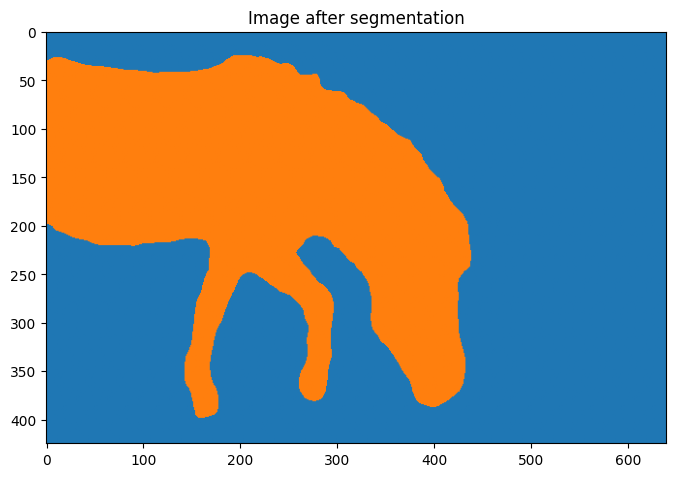

In [ ]:
plt.figure(figsize=(8,8))
a = plt.imread('segmented_image.png')
plt.imshow(a)
plt.title("Image after segmentation")
plt.show()

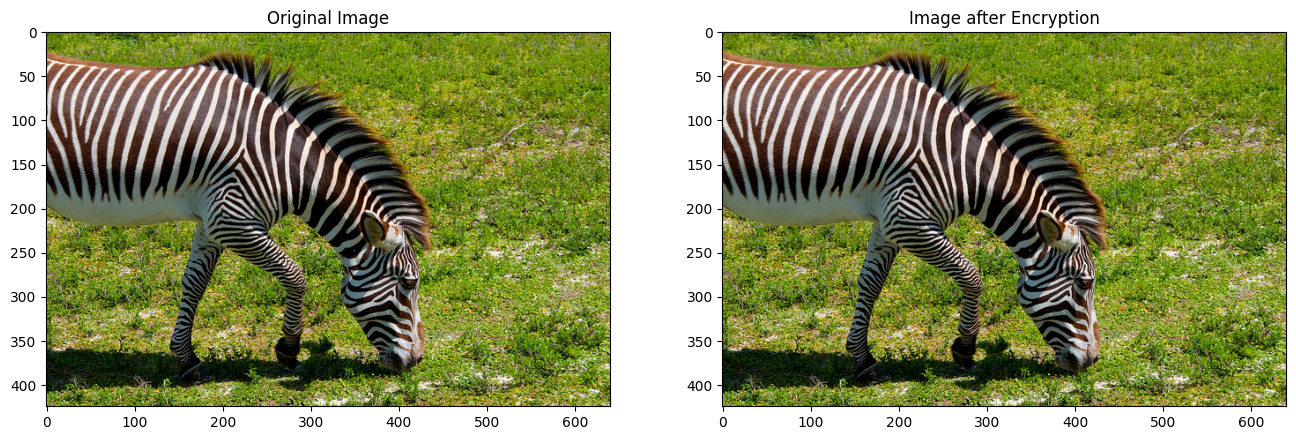

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
a = plt.imread('/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000000034.jpg')
plt.imshow(a)
plt.title('Original Image')

plt.subplot(1,2,2)
a = plt.imread('encrypt_image.png')
plt.imshow(a)
plt.title('Image after Encryption')
plt.show()

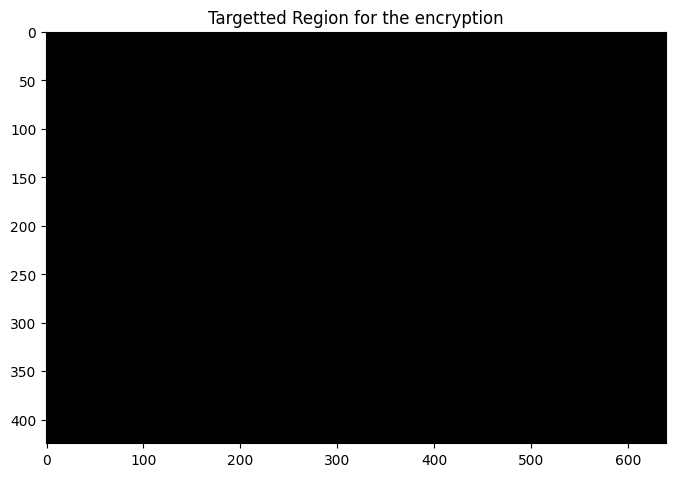

In [ ]:
plt.figure(figsize=(8,8))
a = plt.imread('targetted_segment.png')
plt.imshow(a)
plt.title("Targetted Region for the encryption")
plt.show()

In [ ]:
def decoder_helper(enc_img_path):

    img = plt.imread(enc_img_path)
    seg_id = segmentImage(enc_img_path)

    # find all segment ids
    unique_ids, counts = np.unique(seg_id, return_counts=True)

    # choose the largest segment
    largest_id = unique_ids[np.argmax(counts)]

    idx = np.where(seg_id == largest_id)

    # compute centroid
    cent = int(idx[0].mean()), int(idx[1].mean())

    return cent

In [ ]:
# Decoder Function #
def decode(enc_img_path):
    enc_img = plt.imread(enc_img_path)
    s = 50  # parameter of size of the encrypted image
    png_img = cv2.imread(enc_img_path)
    t = 'enc_img_path.jpg'
    cv2.imwrite(t, png_img, [int(cv2.IMWRITE_JPEG_QUALITY), 100])
    cent_ = decoder_helper(t)
    encrypt_space = enc_img[cent[0]-s:cent[0]+s, cent[1]-s:cent[1]+s, :]
    X = plt.imread("secret.png")
    mt.imsave('en_sp_decript.png', encrypt_space)
    decoded_message = lsb.reveal("secret.png", generators.eratosthenes())
    return decoded_message


In [ ]:
message = decode('encrypt_image.png')
print("Message: \n", message)

Message: 
 
PROJECT euis:
Encryption using Image Segmentation
Team Members:
Rashmi Agrawal
Bhuvana
Pratham

